# Second iteration calculations and plots

In [1]:
import piplite
await piplite.install(['seaborn', 'pandas', 'numpy', 'matplotlib', 'scipy'])
print("Installation complete! You can now run the analysis code.")

Installation complete! You can now run the analysis code.


In [6]:
import os
os.chdir('/drive/notebooks/')
import pandas as pd
import numpy as np


df = pd.read_csv('ActivityFulltable.csv', sep=';', skiprows=1)
df.columns = [col.strip() for col in df.columns]
df['Participant'] = df['Participant'].ffill()
df['Level'] = df['Level'].str.strip()
df['Time Spent'] = pd.to_numeric(df['Time Spent'], errors='coerce').fillna(0)


level_mapping = {
    'Base Chart': 'Base',
    'Line Chart': 'Line',
    'Area Chart': 'Area',
    'Stacked Area': 'Stacked',
    'Stacked Area (1)': 'Stacked',
    'Misleading': 'Misleading'
}
df['GroupedLevel'] = df['Level'].map(level_mapping)

manual_tasks = {
    'Base': 10,
    'Line': 23,
    'Area': 5,
    'Stacked': 28,
    'Misleading': 4
}

stats_list = []

for (participant, level), group in df.groupby(['Participant', 'GroupedLevel']):
    total_time = group['Time Spent'].sum()
    
    seen_activities = set()
    first_attempt_time = 0
    for _, row in group.iterrows():
        act_name = row['Activity Name']
        if act_name not in seen_activities:
            first_attempt_time += row['Time Spent']
            seen_activities.add(act_name)
    
    is_replayer = (group['Returns to Explanation'].str.strip() == 'Yes').any()
    
    stats_list.append({
        'Participant': participant,
        'Level': level,
        'First_Time': first_attempt_time,
        'Total_Time': total_time,
        'Is_Replayer': is_replayer
    })

results_df = pd.DataFrame(stats_list)

agg_table = results_df.groupby('Level').agg(
    First_Mean=('First_Time', 'mean'),
    Total_Mean=('Total_Time', 'mean'),
    Total_SD=('Total_Time', 'std'),
    Replayers_Count=('Is_Replayer', 'sum')
).reset_index()

replays_total = df[df['Returns to Explanation'].str.strip() == 'Yes'].groupby('GroupedLevel').size().reset_index(name='Replays')
replayer_total_time = results_df[results_df['Is_Replayer'] == True].groupby('Level')['Total_Time'].mean().reset_index(name='Total_Replayers')

final_table = agg_table.merge(replays_total, left_on='Level', right_on='GroupedLevel', how='left')
final_table = final_table.merge(replayer_total_time, on='Level', how='left')
final_table['Tasks'] = final_table['Level'].map(manual_tasks)

order = ['Base', 'Line', 'Area', 'Stacked', 'Misleading']
final_table['Level'] = pd.Categorical(final_table['Level'], categories=order, ordered=True)
final_table = final_table.sort_values('Level')

final_table = final_table[[
    'Level', 'Tasks', 'First_Mean', 'Total_Mean', 'Total_SD', 
    'Replays', 'Replayers_Count', 'Total_Replayers'
]]

# Rename for LaTeX compatibility
final_table.columns = [
    'Level', 'Tasks', 'First (s)', 'Total (s)', 'Total (s) SD', 
    'Replays', 'Replayers', 'Total (s) (Replayers)'
]

# Display
print(final_table.round(2).to_string(index=False))

     Level  Tasks  First (s)  Total (s)  Total (s) SD  Replays  Replayers  Total (s) (Replayers)
      Base     10     156.80     194.44        128.90       24         18                 289.72
      Line     23     171.31     190.97        109.29       25         16                 251.94
      Area      5      59.47      76.60         76.02       19         13                 173.46
   Stacked     28     273.19     349.72        227.12       54         28                 442.32
Misleading      4      86.08      96.31         57.45       27         17                 125.35


In [7]:
import os
os.chdir('/drive/notebooks/')
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

df = pd.read_csv('ActivityFulltable.csv', sep=';', skiprows=1)

df.columns = [col.strip() for col in df.columns]
df['Participant'] = df['Participant'].ffill()
df['Level'] = df['Level'].str.strip()
df['Activity Name'] = df['Activity Name'].str.strip()
df['Score'] = pd.to_numeric(df['Score'], errors='coerce').fillna(0)
df['Max Score'] = pd.to_numeric(df['Max Score'], errors='coerce').fillna(0)

level_map = {
    'Base Chart': 'Base Chart',
    'Line Chart': 'Line Chart',
    'Area Chart': 'Area Chart',
    'Stacked Area': 'Stacked Area',
    'Stacked Area (1)': 'Stacked Area',
    'Misleading': 'Misleading'
}
df['GroupedLevel'] = df['Level'].map(level_map)

results_list = []

for (participant, level), group in df.groupby(['Participant', 'GroupedLevel']):
    level_total_max = group.drop_duplicates(subset='Activity Name')['Max Score'].sum()
    if level_total_max == 0: continue

    first_attempt_score = 0
    seen_activities = set()
    for _, row in group.iterrows():
        if row['Activity Name'] in seen_activities:
            break
        first_attempt_score += row['Score']
        seen_activities.add(row['Activity Name'])

    best_attempt = group.drop_duplicates(subset='Activity Name', keep='last')
    best_score_total = best_attempt['Score'].sum()

    results_list.append({
        'Participant': participant,
        'Level': level,
        'Raw_First_Perc': (first_attempt_score / level_total_max) * 100,
        'Best_Perc': (best_score_total / level_total_max) * 100
    })

results_df = pd.DataFrame(results_list)

table_data = []
levels = ['Base Chart', 'Line Chart', 'Area Chart', 'Stacked Area', 'Misleading']

def cohen_d(x, y):
    diff = x - y
    return diff.mean() / diff.std() if diff.std() != 0 else 0

for lvl in levels:
    data = results_df[results_df['Level'] == lvl]
    first = data['Raw_First_Perc']
    best = data['Best_Perc']
    
    t_stat, p_raw = stats.ttest_rel(best, first)
    d_val = cohen_d(best, first)
    
    table_data.append({
        'Level': lvl,
        'First %': first.mean(),
        'Best %': best.mean(),
        'Gain': best.mean() - first.mean(),
        'Delta': t_stat,
        'p_raw': p_raw,
        'Cohen\'s d': d_val
    })

final_table = pd.DataFrame(table_data)
_, p_adj, _, _ = multipletests(final_table['p_raw'], method='bonferroni')
final_table['p-value'] = p_adj

final_table['First %'] = final_table['First %'].map('{:.2f}%'.format)
final_table['Best %'] = final_table['Best %'].map('{:.2f}%'.format)
final_table['Gain'] = final_table['Gain'].map('+{:.1f}%'.format)
final_table['p-value'] = final_table['p-value'].apply(lambda x: '<.001' if x < 0.001 else f'{x:.3f}')

cols = ['Level', 'First %', 'Best %', 'Gain', 'Delta', 'p-value', 'Cohen\'s d']
print(final_table[cols].round(2).to_string(index=False))

       Level First % Best %   Gain  Delta p-value  Cohen's d
  Base Chart  80.59% 87.72%  +7.1%   1.76   0.411       0.21
  Line Chart  80.14% 92.97% +12.8%   3.34   0.007       0.39
  Area Chart  73.78% 93.31% +19.5%   3.35   0.006       0.40
Stacked Area  61.84% 82.66% +20.8%   4.64   <.001       0.55
  Misleading  66.43% 93.20% +26.8%   4.60   <.001       0.55


<ipython-input-9-7d7a9c14549b>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


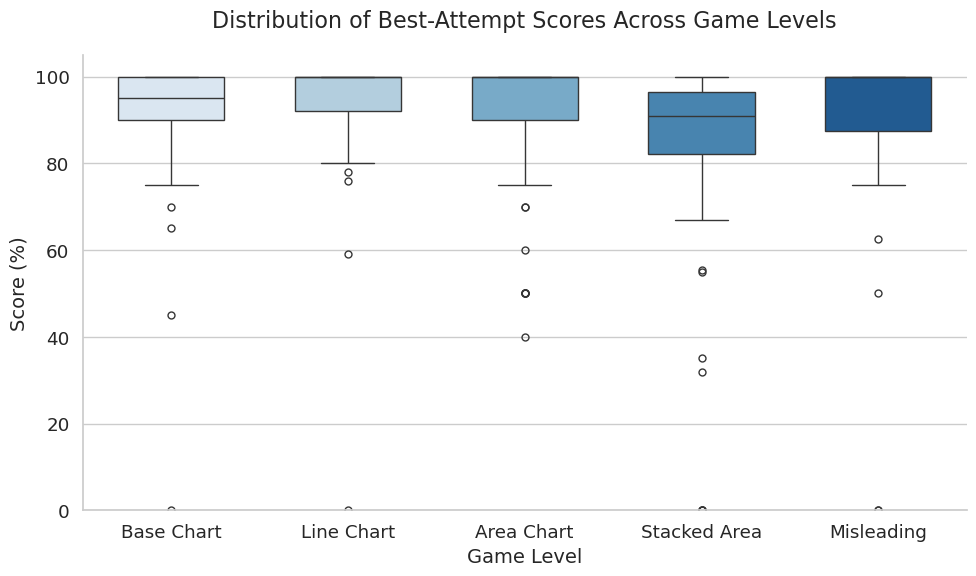

In [9]:
import os
os.chdir('/drive/notebooks/')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Level_summary.csv', sep=';')
df['Participant'] = df['Participant'].ffill()

def clean_pct(val):
    if pd.isna(val): return None
    return float(str(val).replace('%', '').replace('\xa0', '').strip())

df['BestAttemptScore'] = df['BestPercentage'].apply(clean_pct)
df['Level'] = df['Level'].str.strip()

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))

level_order = ['Base Chart', 'Line Chart', 'Area Chart', 'Stacked Area', 'Misleading']

ax = sns.boxplot(
    x='Level', 
    y='BestAttemptScore', 
    data=df, 
    order=level_order,
    palette="Blues", 
    width=0.6,
    showfliers=True,
    fliersize=5     
)

plt.title('Distribution of Best-Attempt Scores Across Game Levels', fontsize=16, pad=20)
plt.ylabel('Score (%)', fontsize=14)
plt.xlabel('Game Level', fontsize=14)
plt.ylim(0, 105)

sns.despine()
plt.tight_layout()

plt.savefig('best_attempt_boxplot.png', dpi=300)
plt.show()

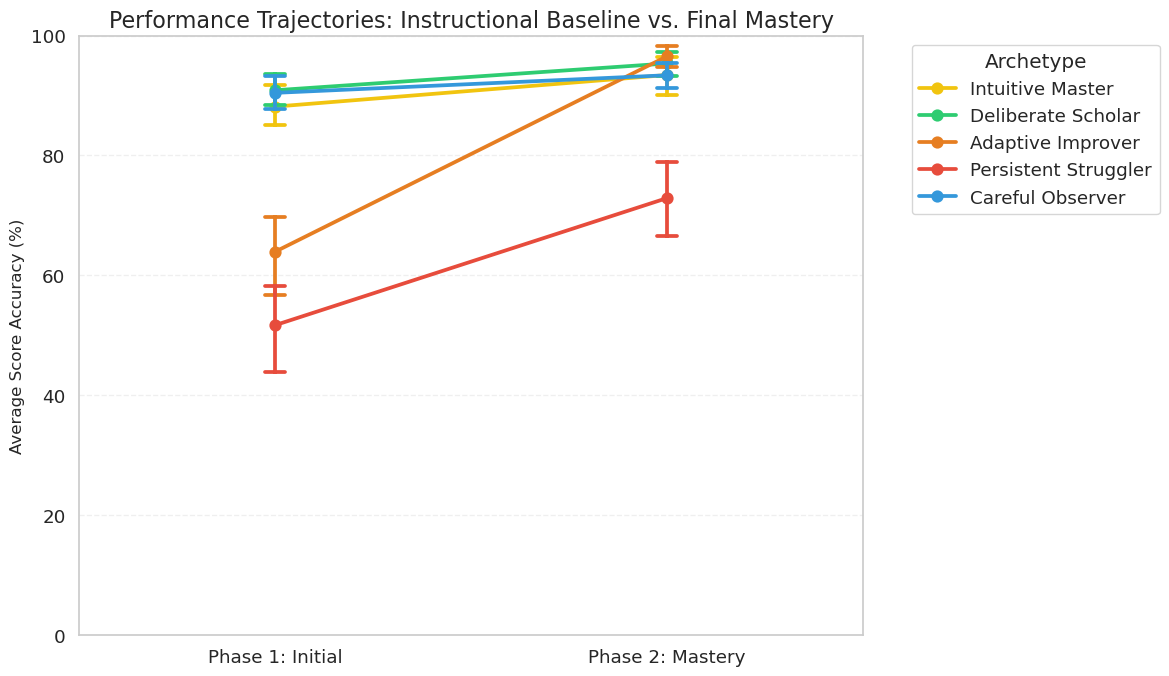

                       FirstAcc    BestAcc  Growth_Delta
Archetype                                               
Adaptive Improver     63.900000  96.541818     32.641818
Persistent Struggler  51.653333  72.884000     21.230667
Intuitive Master      88.136000  93.416000      5.280000
Deliberate Scholar    90.865000  95.338333      4.473333
Careful Observer      90.432500  93.373611      2.941111


In [10]:
import os
os.chdir('/drive/notebooks/')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Level_summary.csv', sep=';')
df['Participant'] = df['Participant'].ffill()

def clean_num(x):
    if pd.isna(x) or str(x).lower() == 'nan' or str(x).strip() == '': return 0.0
    s = str(x).replace('%', '').replace(',', '.').replace('~', '').strip()
    try: return float(s)
    except: return 0.0

df['ReadTime'] = df['Explanation Time (Before Lvl) (s)'].apply(clean_num)
df['FirstAcc'] = df['FirstPercentage'].apply(clean_num)
df['BestAcc'] = df['BestPercentage'].apply(clean_num)
df['TaskTime'] = df['Time Spent (s)'].apply(clean_num)


main_lvls = ['Base Chart', 'Line Chart', 'Area Chart', 'Stacked Area', 'Misleading']
df_main = df[df['Level'].isin(main_lvls)].copy()


p_stats = df_main.groupby('Participant').agg({
    'ReadTime': 'mean',
    'FirstAcc': 'mean',
    'BestAcc': 'mean',
    'TaskTime': 'mean'
})

med_task = p_stats[p_stats['FirstAcc'] >= 78]['TaskTime'].median()

def classify(row):
    if row['FirstAcc'] >= 78:
        if row['ReadTime'] < 32.5: 
            return "Intuitive Master"
        return "Deliberate Scholar" if row['TaskTime'] < med_task else "Careful Observer"
    else:
        return "Adaptive Improver" if row['BestAcc'] >= 90 else "Persistent Struggler"

p_stats['Archetype'] = p_stats.apply(classify, axis=1)
plot_data = p_stats.reset_index().melt(
    id_vars=['Participant', 'Archetype'],
    value_vars=['FirstAcc', 'BestAcc'],
    var_name='Phase',
    value_name='Accuracy'
)
plot_data['Phase'] = plot_data['Phase'].map({'FirstAcc': 'Phase 1: Initial', 'BestAcc': 'Phase 2: Mastery'})

plt.figure(figsize=(12, 7))
palette = {
    "Deliberate Scholar": "#2ecc71", "Careful Observer": "#3498db",
    "Intuitive Master": "#f1c40f", "Adaptive Improver": "#e67e22",
    "Persistent Struggler": "#e74c3c"
}

sns.pointplot(
    data=plot_data, 
    x='Phase', 
    y='Accuracy', 
    hue='Archetype', 
    palette=palette,
    errorbar=('ci', 95), # Standard Error Bars
    capsize=0.05
)

plt.title('Performance Trajectories: Instructional Baseline vs. Final Mastery', fontsize=16)
plt.ylabel('Average Score Accuracy (%)', fontsize=12)
plt.xlabel('') # Removing 'Phase' label for cleanliness
plt.ylim(0, 100)
plt.legend(title='Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

growth_table = p_stats.groupby('Archetype').agg({
    'FirstAcc': 'mean',
    'BestAcc': 'mean'
})
growth_table['Growth_Delta'] = growth_table['BestAcc'] - growth_table['FirstAcc']
print(growth_table.sort_values('Growth_Delta', ascending=False))

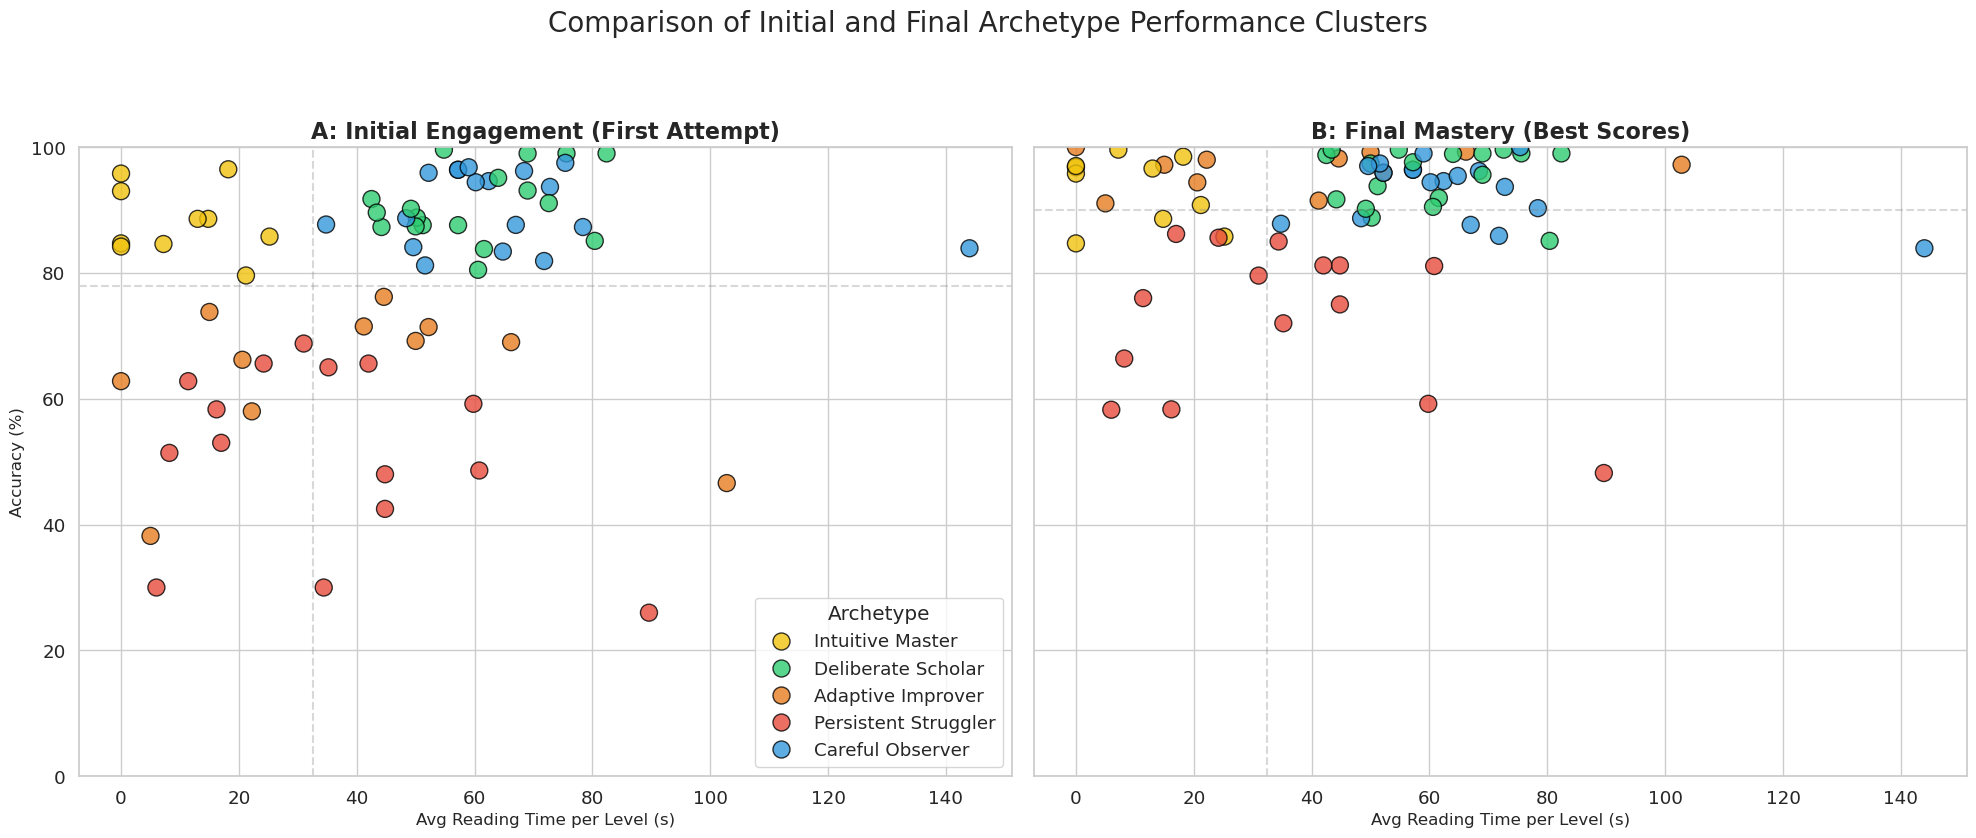

In [11]:
import os
os.chdir('/drive/notebooks/')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Level_summary.csv', sep=';')
df['Participant'] = df['Participant'].ffill()

def clean_num(x):
    if pd.isna(x) or str(x).lower() == 'nan' or str(x).strip() == '': return 0.0
    s = str(x).replace('%', '').replace(',', '.').replace('~', '').strip()
    try: return float(s)
    except: return 0.0

df['ReadTime'] = df['Explanation Time (Before Lvl) (s)'].apply(clean_num)
df['FirstAcc'] = df['FirstPercentage'].apply(clean_num)
df['BestAcc'] = df['BestPercentage'].apply(clean_num)
df['TaskTime'] = df['Time Spent (s)'].apply(clean_num)

main_lvls = ['Base Chart', 'Line Chart', 'Area Chart', 'Stacked Area', 'Misleading']
df_main = df[df['Level'].isin(main_lvls)].copy()

p_stats = df_main.groupby('Participant').agg({
    'ReadTime': 'mean',
    'FirstAcc': 'mean',
    'BestAcc': 'mean',
    'TaskTime': 'mean'
})

med_task = p_stats[p_stats['FirstAcc'] >= 78]['TaskTime'].median()

def classify(row):
    if row['FirstAcc'] >= 78:
        if row['ReadTime'] < 32.5: 
            return "Intuitive Master"
        return "Deliberate Scholar" if row['TaskTime'] < med_task else "Careful Observer"
    else:
        return "Adaptive Improver" if row['BestAcc'] >= 90 else "Persistent Struggler"

p_stats['Archetype'] = p_stats.apply(classify, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

palette = {
    "Deliberate Scholar": "#2ecc71", "Careful Observer": "#3498db",
    "Intuitive Master": "#f1c40f", "Adaptive Improver": "#e67e22",
    "Persistent Struggler": "#e74c3c"
}

sns.scatterplot(data=p_stats, x='ReadTime', y='FirstAcc', hue='Archetype', 
                palette=palette, s=150, alpha=0.8, ax=ax1, edgecolor='black')
ax1.set_title('A: Initial Engagement (First Attempt)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Avg Reading Time per Level (s)', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.axvline(x=32.5, color='grey', linestyle='--', alpha=0.3)
ax1.axhline(y=78, color='grey', linestyle='--', alpha=0.3)
ax1.set_ylim(0, 100)

sns.scatterplot(data=p_stats, x='ReadTime', y='BestAcc', hue='Archetype', 
                palette=palette, s=150, alpha=0.8, ax=ax2, edgecolor='black', legend=False)
ax2.set_title('B: Final Mastery (Best Scores)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Avg Reading Time per Level (s)', fontsize=12)
ax2.axvline(x=32.5, color='grey', linestyle='--', alpha=0.3)
ax2.axhline(y=90, color='grey', linestyle='--', alpha=0.3)
ax2.set_ylim(0, 100)

plt.suptitle('Comparison of Initial and Final Archetype Performance Clusters', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()



In [43]:
import os
os.chdir('/drive/notebooks/')

import pandas as pd
import numpy as np

df = pd.read_csv("Level_summary.csv", sep=';')
df.columns = [c.strip() for c in df.columns]
df['Participant'] = df['Participant'].ffill()

def parse_pct(val):
    if pd.isna(val):
        return np.nan
    s = str(val).replace('%', '').replace(',', '.').strip()
    try:
        return float(s)
    except:
        return np.nan

def parse_num(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace('~', '')
    try:
        return float(s)
    except:
        return np.nan

df['BestPct'] = df['BestPercentage'].apply(parse_pct)
df['ExplTime'] = df['Explanation Time (Before Lvl) (s)'].apply(parse_num)

def normalize_level(name):
    s = str(name).lower().strip()
    if 'misleading' in s: return 'Misleading'
    elif 'stacked' in s: return 'Stacked Area'
    elif 'area' in s: return 'Area Chart'
    elif 'line' in s: return 'Line Chart'
    elif 'base' in s: return 'Base Chart'
    return name

df['Level'] = df['Level'].apply(normalize_level)
LEVELS = ['Base Chart', 'Line Chart', 'Area Chart', 'Stacked Area', 'Misleading']

first_rows = df.groupby(['Participant', 'Level']).first().reset_index()
best_pct = df.groupby(['Participant', 'Level'])['BestPct'].max().reset_index()

print("\n EXPLANATION TIME (Initial Read)")
for level in LEVELS:
    ld = first_rows[first_rows['Level'] == level]['ExplTime'].dropna()
    print(f"  {level:18s}  M = {ld.mean():5.1f}s  SD = {ld.std():5.1f}s  Median = {ld.median():.0f}s")

print("\n BEST SCORE DISTRIBUTION")
for level in LEVELS:
    vals = best_pct[best_pct['Level'] == level]['BestPct'].dropna()
    print(f"  {level:18s}  M = {vals.mean():5.1f}%  Median = {vals.median():.0f}%  "
          f"Min = {vals.min():.0f}%  Max = {vals.max():.0f}%")


 EXPLANATION TIME (Initial Read)
  Base Chart          M =  43.0s  SD =  35.9s  Median = 47s
  Line Chart          M =  47.0s  SD =  33.5s  Median = 46s
  Area Chart          M =  43.1s  SD =  29.2s  Median = 44s
  Stacked Area        M =  63.8s  SD =  47.9s  Median = 65s
  Misleading          M =  45.7s  SD =  30.2s  Median = 54s

 BEST SCORE DISTRIBUTION
  Base Chart          M =  91.3%  Median = 95%  Min = 0%  Max = 100%
  Line Chart          M =  93.9%  Median = 100%  Min = 0%  Max = 100%
  Area Chart          M =  91.2%  Median = 100%  Min = 40%  Max = 100%
  Stacked Area        M =  83.4%  Median = 91%  Min = 0%  Max = 100%
  Misleading          M =  90.8%  Median = 100%  Min = 0%  Max = 100%
